<a href="https://colab.research.google.com/github/rianviniciusfr/Rian-Vinicius/blob/main/Regressaolinearicecream.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("raphaelmanayon/temperature-and-ice-cream-sales")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'temperature-and-ice-cream-sales' dataset.
Path to dataset files: /kaggle/input/temperature-and-ice-cream-sales


In [6]:
import pandas as pd
import os

# The correct CSV file name has been identified.
dataset_file = os.path.join(path, 'Ice Cream Sales - temperatures.csv')

# Load the dataset into a pandas DataFrame
df = pd.read_csv(dataset_file)

# Display the first few rows of the DataFrame
print("DataFrame created successfully. Here's a preview:")
df.head()

DataFrame created successfully. Here's a preview:


,Temperature,Ice Cream Profits
0,39,13.17
1,40,11.88
2,41,18.82
3,42,18.65
4,43,17.02


## Linear Regression

We will perform a linear regression to understand the relationship between 'Temperature' and 'Ice Cream Profits'.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Define features (X) and target (y)
# X is 'Temperature', and y is 'Ice Cream Profits'
X = df[['Temperature']]
y = df['Ice Cream Profits']

print("Features (X) and Target (y) defined.")
print("X head:\n", X.head())
print("y head:\n", y.head())

Features (X) and Target (y) defined.
X head:
    Temperature
0           39
1           40
2           41
3           42
4           43
y head:
 0    13.17
1    11.88
2    18.82
3    18.65
4    17.02
Name: Ice Cream Profits, dtype: float64


Next, we'll split the data into training and testing sets. This allows us to train the model on a portion of the data and then evaluate its performance on unseen data.

In [10]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Training set size: 292 samples
Testing set size: 73 samples


Now, let's create and train the linear regression model using the training data.

In [15]:
# Create a linear regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")
print(f"Coefficient (slope): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")
print(F"Regression Equatyon:+= y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}")

Linear Regression model trained successfully.
Coefficient (slope): 1.19
Intercept: -33.66
Regression Equatyon:+= y = 1.19x + -33.66


With the model trained, we can now make predictions on the test set and evaluate the model's performance using metrics like Mean Squared Error (MSE) and R-squared.

In [12]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 5.29
R-squared (R2): 0.98


Finally, let's visualize the linear regression line along with the actual data points to see how well the model fits.

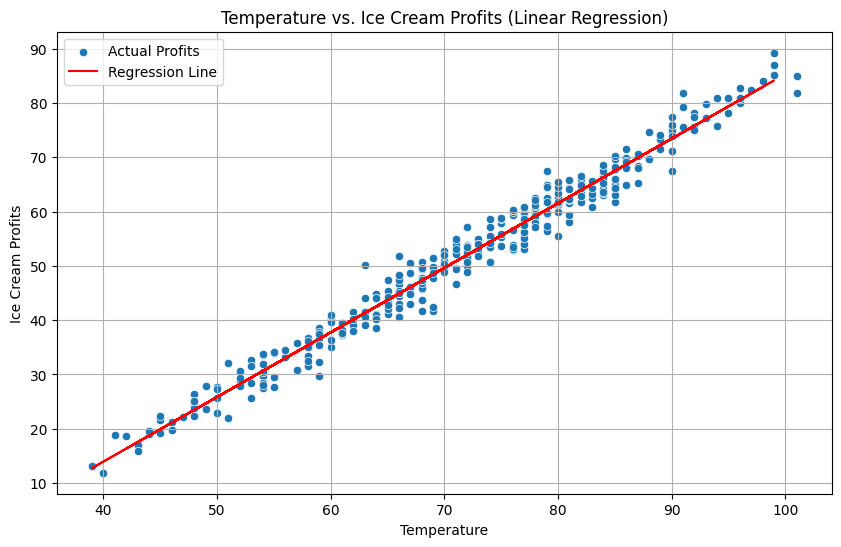

In [22]:
# Plot the results
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Temperature'], y=df['Ice Cream Profits'], label='Actual Profits')
plt.plot(X_test, y_pred, color='red', label='Regression Line')
plt.title('Temperature vs. Ice Cream Profits (Linear Regression)')
plt.xlabel('Temperature')
plt.ylabel('Ice Cream Profits')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# Removed the problematic internal function call.